# 13 — Audio Capture & Offline Beamforming

**Goal**: validate the full audio capture → CSM → beamforming pipeline
on real data from the ReSpeaker XVF3800 4-mic array.

Steps:
1. Discover the device via sounddevice
2. Analyse the channel structure (6 channels: 4 mics + 2 beamformed outputs)
3. Record a fresh live clip
4. Compute the Cross-Spectral Matrix (CSM) from the 4 mic channels
5. Beamform with D&S, MVDR, and CLEAN-SC and plot energy maps
6. Cross-check against the device's onboard DoA estimate (if pyusb available)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sounddevice as sd
import scipy.io.wavfile as wavfile
import scipy.signal as signal
from scipy.linalg import inv
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C       = 343.0
RADIUS  = 0.045        # 90mm aperture / 2
FS      = 16000        # ReSpeaker sample rate
N_MICS  = 4            # channels 0-3 are mic channels
FREQ_BF = 1500.0       # beamforming centre frequency (safely below Nyquist)

# Nominal 4-mic circular geometry (will be refined after AEC_MIC_ARRAY_GEO read)
angles_deg = np.array([0.0, 90.0, 180.0, 270.0])
x = RADIUS * np.cos(np.radians(angles_deg))
y = RADIUS * np.sin(np.radians(angles_deg))

WAV_EXISTING = Path('../test/ReSpeaker/output.wav')
WAV_LIVE     = Path('../test/ReSpeaker/capture_nb13.wav')


## 1 — Device Discovery

Find the ReSpeaker in the sounddevice device list and confirm it exposes
6 input channels at 16 kHz.


In [2]:
devs = sd.query_devices()
print(f'All input devices:')
for i, d in enumerate(devs):
    if d['max_input_channels'] > 0:
        print(f'  [{i:2d}] {d["name"]:50s}  '
              f'{d["max_input_channels"]}ch  '
              f'{d["default_samplerate"]:.0f}Hz')

# Find ReSpeaker
rs_idx = None
for i, d in enumerate(devs):
    if 'respeaker' in d['name'].lower() or 'xvf' in d['name'].lower():
        rs_idx = i
        rs_dev = d
        break

if rs_idx is None:
    print('WARNING: ReSpeaker not found — check USB connection')
else:
    print(f'\nReSpeaker found at device index {rs_idx}:')
    print(f'  Name:     {rs_dev["name"]}')
    print(f'  Channels: {rs_dev["max_input_channels"]}')
    print(f'  Rate:     {rs_dev["default_samplerate"]:.0f} Hz')
    print(f'  Latency:  {rs_dev["default_low_input_latency"]*1000:.1f} ms (low)')


All input devices:
  [ 0] HDA Intel PCH: ALC1220 Analog (hw:0,0)              2ch  44100Hz
  [ 2] HDA Intel PCH: ALC1220 Alt Analog (hw:0,2)          2ch  44100Hz
  [11] Logitech BRIO: USB Audio (hw:3,0)                   2ch  48000Hz
  [12] reSpeaker XVF3800 4-Mic Array: USB Audio (hw:4,0)   6ch  16000Hz
  [13] sysdefault                                          128ch  48000Hz
  [23] pipewire                                            64ch  44100Hz
  [25] default                                             64ch  44100Hz

ReSpeaker found at device index 12:
  Name:     reSpeaker XVF3800 4-Mic Array: USB Audio (hw:4,0)
  Channels: 6
  Rate:     16000 Hz
  Latency:  23.9 ms (low)


## 2 — Channel Analysis (Existing Recording)

The file `test/ReSpeaker/output.wav` was captured earlier (6 channels, 16 kHz, 16-bit).
Analyse each channel to determine which are mic signals vs processed outputs.

Expected channel layout (XVF3800 default):
- Channels 0–3: raw or AEC-residual mic signals (one per mic)
- Channels 4–5: beamformed / post-processed stereo output


In [3]:
fs_wav, data_raw = wavfile.read(WAV_EXISTING)
data = data_raw.astype(np.float32) / 32768.0   # normalise to ±1
n_samp, n_ch = data.shape
duration = n_samp / fs_wav
print(f'File: {WAV_EXISTING}')
print(f'Channels: {n_ch},  Rate: {fs_wav} Hz,  Duration: {duration:.2f} s')
print(f'Max absolute values per channel:')
for ch in range(n_ch):
    rms = np.sqrt(np.mean(data[:, ch]**2))
    pk  = np.abs(data[:, ch]).max()
    print(f'  ch{ch}: RMS={rms:.5f}  peak={pk:.5f}')


File: ../test/ReSpeaker/output.wav
Channels: 6,  Rate: 16000 Hz,  Duration: 10.00 s
Max absolute values per channel:
  ch0: RMS=0.01599  peak=0.24100
  ch1: RMS=0.00275  peak=0.06430
  ch2: RMS=0.00278  peak=0.06293
  ch3: RMS=0.00260  peak=0.06125
  ch4: RMS=0.00257  peak=0.06171
  ch5: RMS=0.00000  peak=0.00000


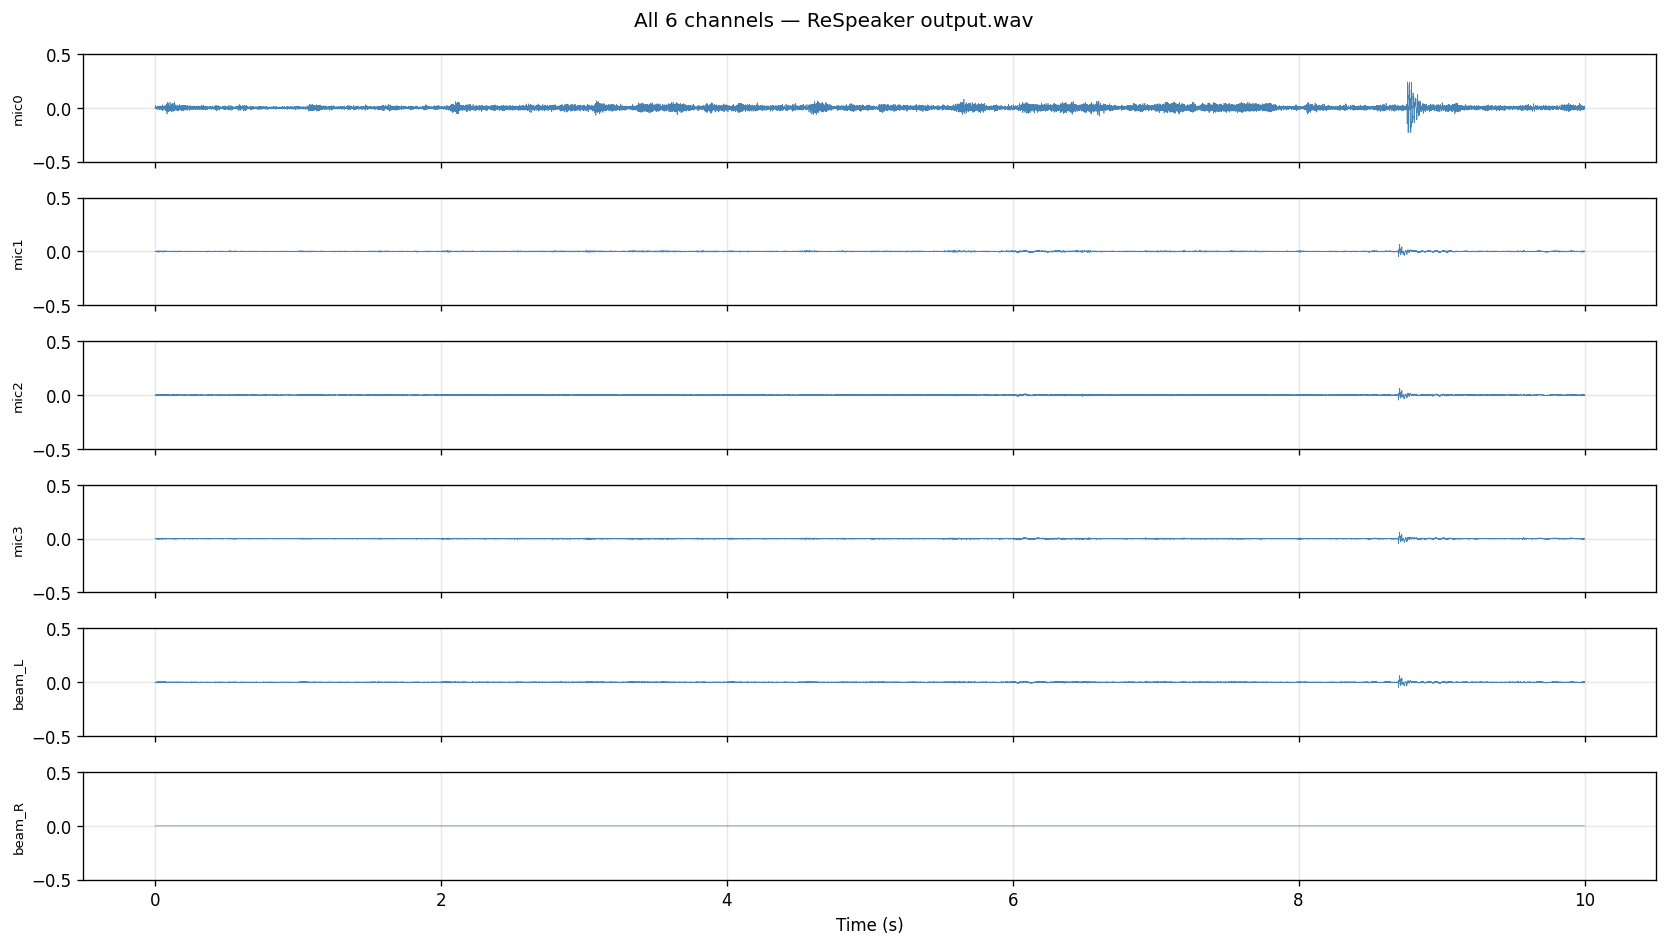

In [4]:
t = np.arange(n_samp) / fs_wav
fig, axes = plt.subplots(n_ch, 1, figsize=(14, 8), sharex=True)
ch_labels = ['mic0', 'mic1', 'mic2', 'mic3', 'beam_L', 'beam_R']
for ch in range(n_ch):
    axes[ch].plot(t, data[:, ch], linewidth=0.4, color='steelblue')
    axes[ch].set_ylabel(ch_labels[ch], fontsize=8)
    axes[ch].set_ylim(-0.5, 0.5)
    axes[ch].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('All 6 channels — ReSpeaker output.wav')
plt.tight_layout()
plt.savefig('respeaker_channels_waveform.png', dpi=150, bbox_inches='tight')
plt.show()


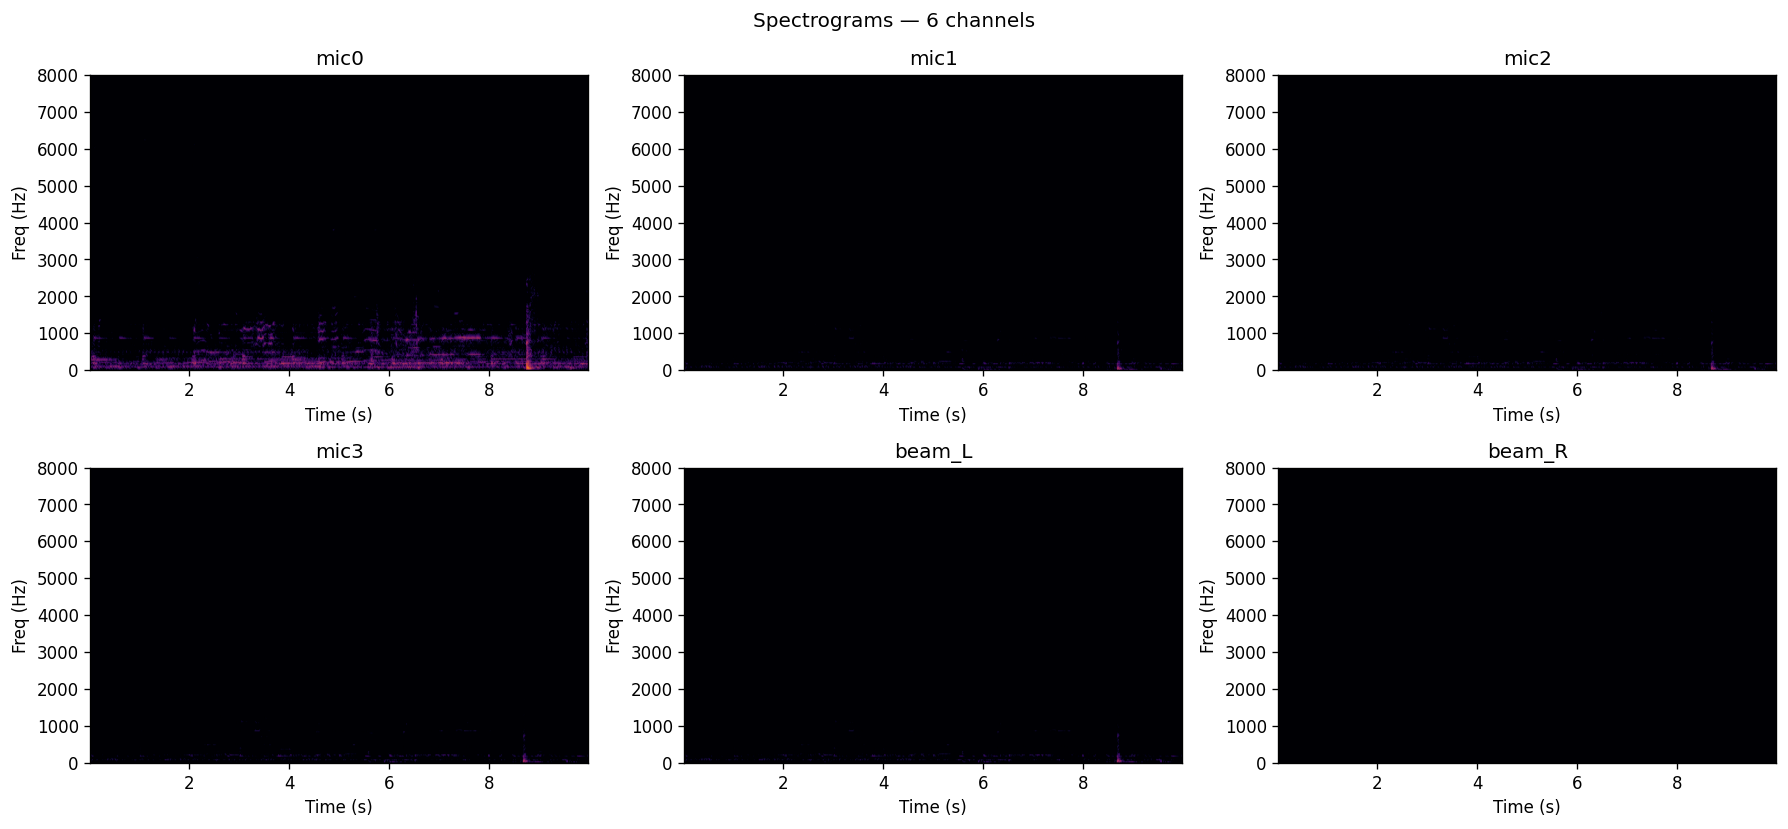

In [5]:
# Spectrogram of all channels to see frequency content
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for ch in range(n_ch):
    f_s, t_s, Sxx = signal.spectrogram(data[:, ch], fs=fs_wav,
                                        nperseg=512, noverlap=384)
    axes[ch].pcolormesh(t_s, f_s, 10*np.log10(Sxx + 1e-10),
                        shading='gouraud', cmap='inferno', vmin=-80, vmax=-20)
    axes[ch].set_ylim(0, fs_wav/2)
    axes[ch].set_title(ch_labels[ch])
    axes[ch].set_xlabel('Time (s)')
    axes[ch].set_ylabel('Freq (Hz)')
plt.suptitle('Spectrograms — 6 channels')
plt.tight_layout()
plt.savefig('respeaker_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()


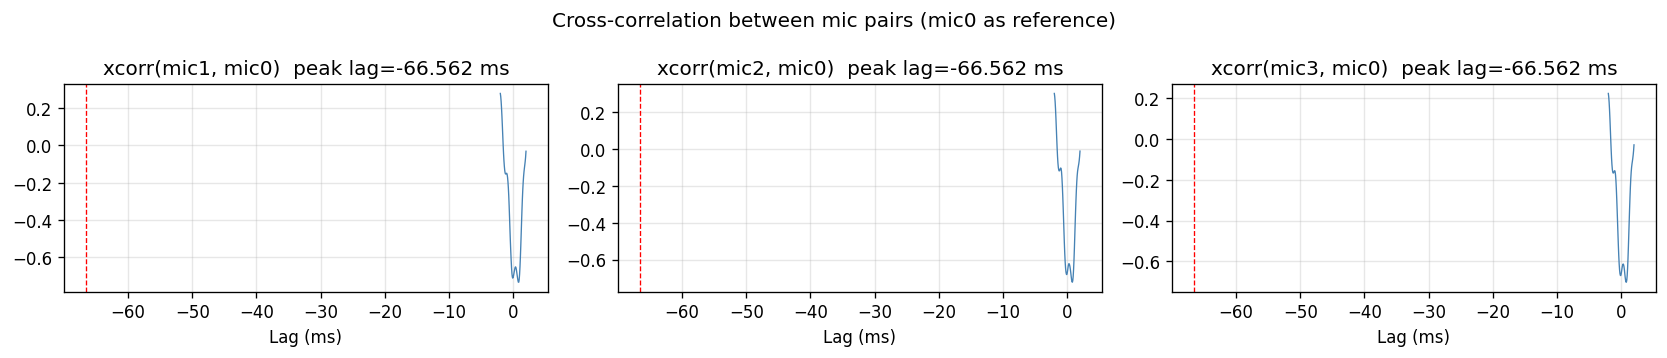

In [6]:
# Cross-correlation between mic pairs to check timing consistency
# Mic channels should show small inter-channel delays; processed channels may look different
mic_data = data[:, :4]    # channels 0-3
ref = mic_data[:, 0]

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i, (ch, ax) in enumerate(zip([1, 2, 3], axes)):
    xcorr = np.correlate(mic_data[:, ch], ref, mode='full')
    lags  = np.arange(-len(ref) + 1, len(ref)) / fs_wav * 1000  # ms
    # zoom to ±2ms
    mask = np.abs(lags) <= 2
    ax.plot(lags[mask], xcorr[mask], linewidth=0.8, color='steelblue')
    peak_lag = lags[np.argmax(xcorr)]
    ax.axvline(peak_lag, color='r', linestyle='--', linewidth=0.8)
    ax.set_title(f'xcorr(mic{ch}, mic0)  peak lag={peak_lag:.3f} ms')
    ax.set_xlabel('Lag (ms)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Cross-correlation between mic pairs (mic0 as reference)')
plt.tight_layout()
plt.savefig('respeaker_xcorr.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 — Live Recording

Record 3 seconds from the device.  Make a sound (clap, tone, speech)
during recording from a known direction if possible.

If recording fails (device busy or not found) the notebook falls back to
the existing WAV for the beamforming sections.


In [7]:
RECORD_SECS = 3
N_CHANNELS  = 6

if rs_idx is not None:
    try:
        print(f'Recording {RECORD_SECS}s from device {rs_idx}  '
              f'("{rs_dev["name"]}")  ...', end=' ', flush=True)
        rec = sd.rec(int(RECORD_SECS * FS), samplerate=FS,
                     channels=N_CHANNELS, dtype='float32', device=rs_idx)
        sd.wait()
        print('done')
        # Save
        WAV_LIVE.parent.mkdir(parents=True, exist_ok=True)
        wavfile.write(WAV_LIVE, FS, (rec * 32767).astype(np.int16))
        print(f'Saved {WAV_LIVE}')
        live_data = rec
        live_ok   = True
    except Exception as e:
        print(f'Recording failed: {e}')
        live_ok = False
else:
    print('No device — skipping live recording.')
    live_ok = False

# Choose which data to use for beamforming
if live_ok:
    bf_data = live_data[:, :N_MICS]
    source_label = 'Live recording'
else:
    bf_data = data[:, :N_MICS]
    source_label = 'Existing output.wav'

print(f'Using: {source_label}  shape={bf_data.shape}')


Recording 3s from device 12  ("reSpeaker XVF3800 4-Mic Array: USB Audio (hw:4,0)")  ... 

done
Saved ../test/ReSpeaker/capture_nb13.wav
Using: Live recording  shape=(48000, 4)


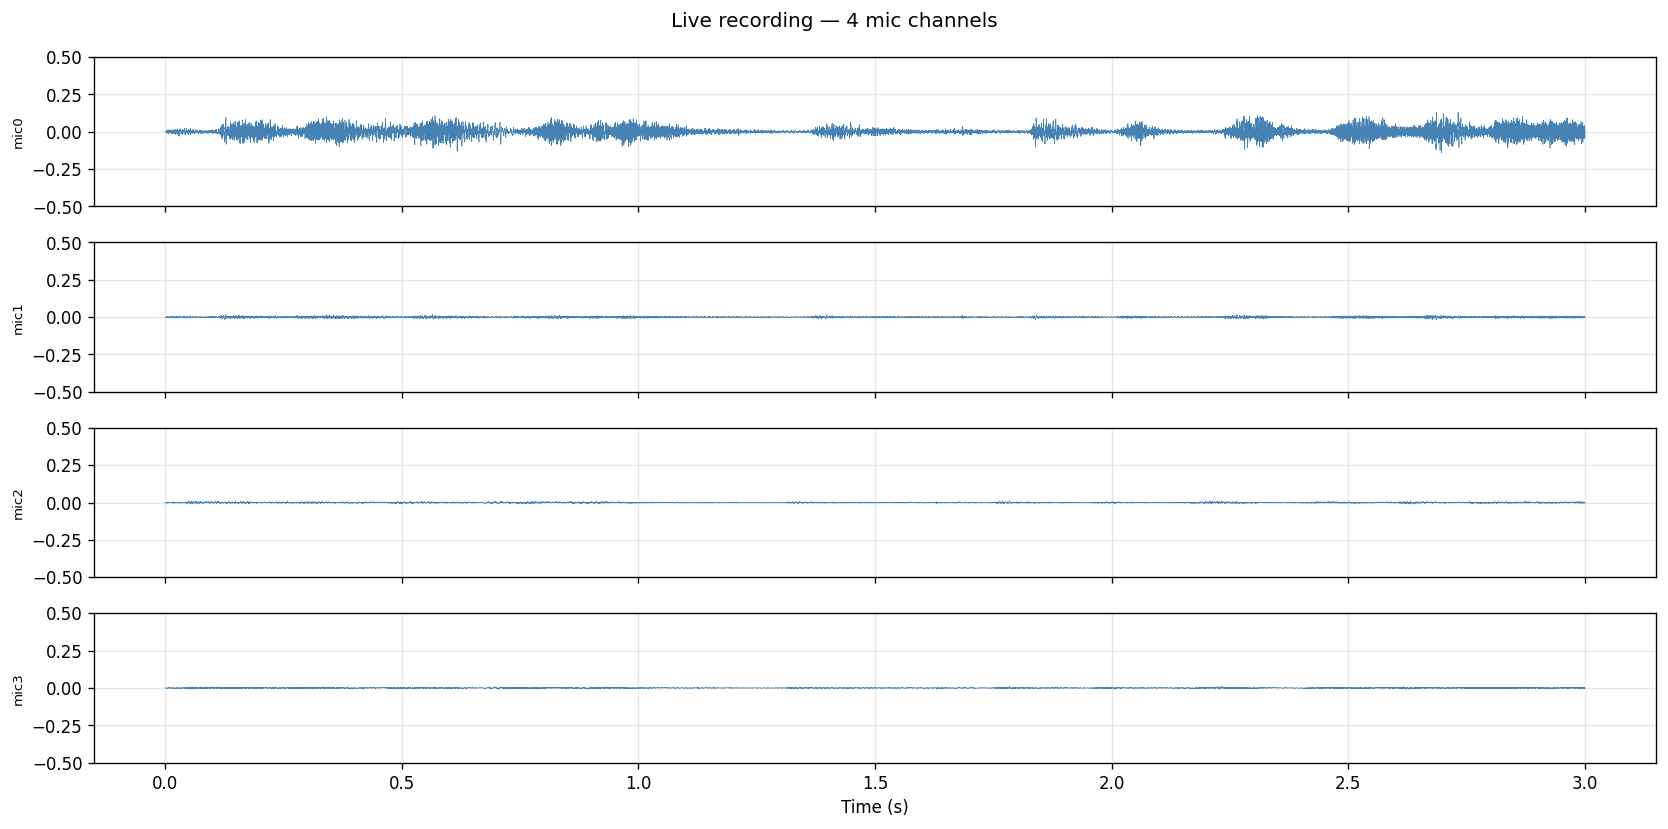

In [8]:
if live_ok:
    t_live = np.arange(live_data.shape[0]) / FS
    fig, axes = plt.subplots(4, 1, figsize=(14, 7), sharex=True)
    for ch in range(4):
        axes[ch].plot(t_live, live_data[:, ch], linewidth=0.4, color='steelblue')
        axes[ch].set_ylabel(f'mic{ch}', fontsize=8)
        axes[ch].set_ylim(-0.5, 0.5)
        axes[ch].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle('Live recording — 4 mic channels')
    plt.tight_layout()
    plt.savefig('respeaker_live_waveform.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No live recording to plot.')


## 4 — Cross-Spectral Matrix and Beamforming

Compute the frequency-domain CSM from the 4 mic channels using Welch-style
block averaging, then apply D&S, MVDR, and CLEAN-SC.

Frequency: 1500 Hz (safely below the ~2695 Hz spatial Nyquist).


In [9]:
def compute_csm(audio, fs, freq, block_size=256, hop=128):
    """Welch-style CSM: average outer products over overlapping FFT blocks."""
    n_samp, n_ch = audio.shape
    freqs   = np.fft.rfftfreq(block_size, 1/fs)
    f_idx   = np.argmin(np.abs(freqs - freq))
    f_actual = freqs[f_idx]
    R = np.zeros((n_ch, n_ch), dtype=complex)
    count = 0
    win = np.hanning(block_size)
    for start in range(0, n_samp - block_size, hop):
        block = audio[start:start + block_size] * win[:, np.newaxis]
        F = np.fft.rfft(block, axis=0)[f_idx]   # (n_ch,) complex
        R    += np.outer(F, F.conj())
        count += 1
    return R / count, f_actual, count


def sm(x, y, az_grid, freq):
    u = np.sin(np.radians(az_grid))
    return np.exp(1j * 2 * np.pi * freq / C * np.outer(x, u)) / np.sqrt(len(x))


def beamform_ds(x, y, R, freq, az_grid):
    H = sm(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N  = R.shape[0]
    Rl = R + diag_load * np.trace(R) / N * np.eye(N)
    Ri = inv(Rl)
    H  = sm(x, y, az_grid, freq)
    d  = np.real(np.sum(H.conj() * (Ri @ H), axis=0))
    return 1.0 / np.maximum(d, 1e-300)


def clean_sc(x, y, R, freq, az_grid, n_iter=40, loop_gain=0.5):
    H     = sm(x, y, az_grid, freq)
    R_w   = R.copy()
    clean = np.zeros(len(az_grid))
    for _ in range(n_iter):
        P = np.real(np.sum(H.conj() * (R_w @ H), axis=0))
        k = np.argmax(P)
        g = R_w @ H[:, k]
        R_w   -= loop_gain * np.outer(g, g.conj())
        clean[k] += loop_gain * np.real(g.conj() @ g)
    return clean


def db_norm(p):
    return 10 * np.log10(np.maximum(p / p.max(), 1e-10))


az_grid = np.linspace(-90, 90, 1801)

R_csm, f_act, n_blocks = compute_csm(bf_data, FS, FREQ_BF)
print(f'CSM computed at {f_act:.1f} Hz using {n_blocks} blocks')
print(f'CSM shape: {R_csm.shape},  trace = {np.trace(R_csm).real:.4f}')
print(f'\nCSM diagonal (power per mic):')
for ch in range(N_MICS):
    print(f'  mic{ch}: {R_csm[ch,ch].real:.6f}')


CSM computed at 1500.0 Hz using 373 blocks
CSM shape: (4, 4),  trace = 0.0403

CSM diagonal (power per mic):
  mic0: 0.039766
  mic1: 0.000342
  mic2: 0.000098
  mic3: 0.000090


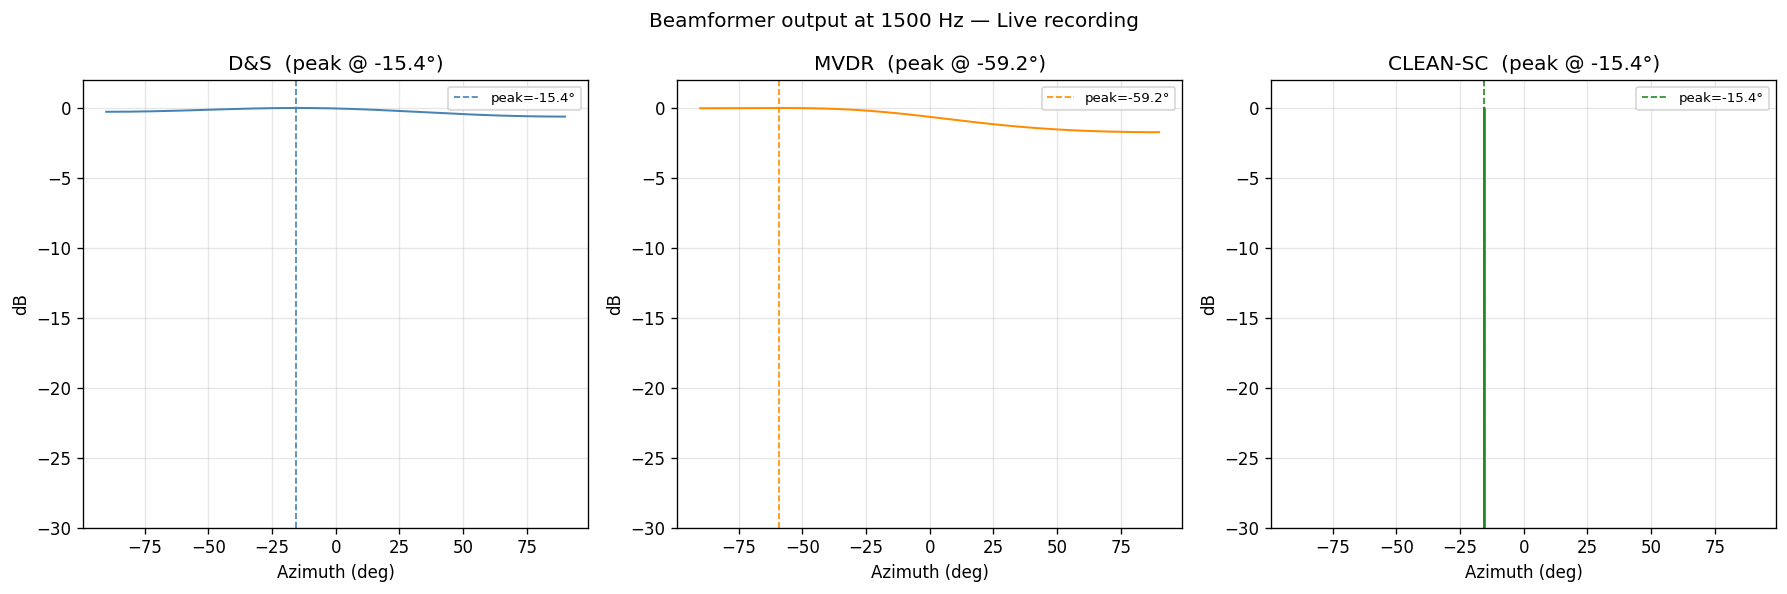

Peak DoA estimates at 1500 Hz:
  D&S:      -15.4°
  MVDR:     -59.2°
  CLEAN-SC: -15.4°


In [10]:
P_ds    = beamform_ds(x, y, R_csm, f_act, az_grid)
P_mvdr  = beamform_mvdr(x, y, R_csm, f_act, az_grid)
P_clean = clean_sc(x, y, R_csm, f_act, az_grid)

az_ds    = az_grid[np.argmax(P_ds)]
az_mvdr  = az_grid[np.argmax(P_mvdr)]
az_clean = az_grid[np.argmax(P_clean)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, (name, P, col, az_est) in zip(axes, [
    ('D&S',      P_ds,    'steelblue',   az_ds),
    ('MVDR',     P_mvdr,  'darkorange',  az_mvdr),
    ('CLEAN-SC', P_clean, 'forestgreen', az_clean),
]):
    ax.plot(az_grid, db_norm(P), color=col, linewidth=1.2)
    ax.axvline(az_est, color=col, linestyle='--', linewidth=1,
               label=f'peak={az_est:.1f}°')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('dB')
    ax.set_title(f'{name}  (peak @ {az_est:.1f}°)')
    ax.set_ylim(-30, 2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Beamformer output at {f_act:.0f} Hz — {source_label}')
plt.tight_layout()
plt.savefig('respeaker_beamform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak DoA estimates at {f_act:.0f} Hz:')
print(f'  D&S:      {az_ds:.1f}°')
print(f'  MVDR:     {az_mvdr:.1f}°')
print(f'  CLEAN-SC: {az_clean:.1f}°')


## 5 — Beamformer Peak vs Frequency

Check whether the dominant source direction is consistent across the
beamforming range (500–2400 Hz).  A stable peak across frequencies
indicates a coherent source; a wandering peak indicates ambient noise.


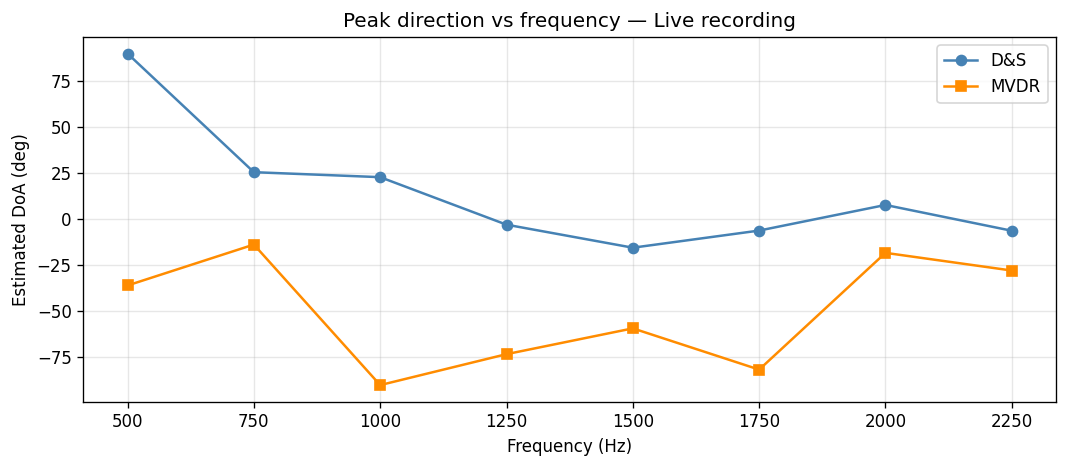

Peak DoA by frequency (D&S | MVDR):
    500 Hz:  D&S= +90.0°   MVDR= -35.9°
    750 Hz:  D&S= +25.6°   MVDR= -13.7°
   1000 Hz:  D&S= +22.9°   MVDR= -90.0°
   1250 Hz:  D&S=  -2.9°   MVDR= -73.2°
   1500 Hz:  D&S= -15.4°   MVDR= -59.2°
   1750 Hz:  D&S=  -6.1°   MVDR= -81.6°
   2000 Hz:  D&S=  +7.8°   MVDR= -18.2°
   2250 Hz:  D&S=  -6.2°   MVDR= -27.8°


In [11]:
FREQS_SWEEP = [500, 750, 1000, 1250, 1500, 1750, 2000, 2250]

peak_ds   = []
peak_mvdr = []

for freq in FREQS_SWEEP:
    R_f, f_a, _ = compute_csm(bf_data, FS, freq)
    P_d = beamform_ds(x, y, R_f, f_a, az_grid)
    P_m = beamform_mvdr(x, y, R_f, f_a, az_grid)
    peak_ds.append(az_grid[np.argmax(P_d)])
    peak_mvdr.append(az_grid[np.argmax(P_m)])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(FREQS_SWEEP, peak_ds,   'o-', color='steelblue',  label='D&S',  linewidth=1.5)
ax.plot(FREQS_SWEEP, peak_mvdr, 's-', color='darkorange', label='MVDR', linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Estimated DoA (deg)')
ax.set_title(f'Peak direction vs frequency — {source_label}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('respeaker_freq_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print('Peak DoA by frequency (D&S | MVDR):')
for freq, pd, pm in zip(FREQS_SWEEP, peak_ds, peak_mvdr):
    print(f'  {freq:5d} Hz:  D&S={pd:+6.1f}°   MVDR={pm:+6.1f}°')


## 6 — CSM Structure

Visualise the CSM magnitude to confirm it looks physically reasonable:
- Diagonal should be the largest (power per mic)
- Off-diagonal should show the inter-mic correlations
- All mics should have similar diagonal power (confirms calibration baseline)


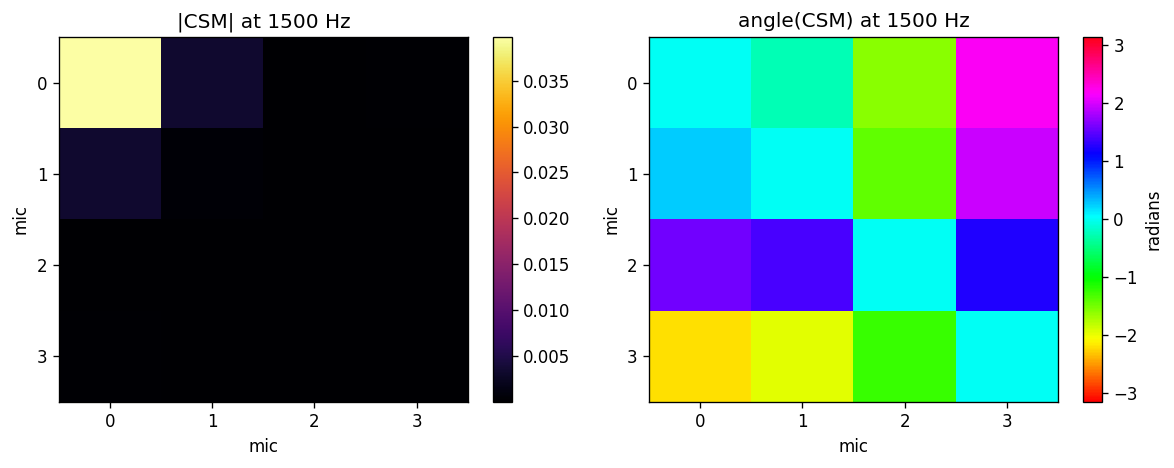

Inter-mic coherence matrix (off-diagonal = coherence between mic pairs):
[[1.    0.894 0.08  0.098]
 [0.894 1.    0.062 0.088]
 [0.08  0.062 1.    0.617]
 [0.098 0.088 0.617 1.   ]]


In [12]:
R_csm_show, f_show, _ = compute_csm(bf_data, FS, FREQ_BF)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Magnitude
im0 = axes[0].imshow(np.abs(R_csm_show), cmap='inferno', aspect='auto')
axes[0].set_title(f'|CSM| at {f_show:.0f} Hz')
axes[0].set_xlabel('mic'); axes[0].set_ylabel('mic')
axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
plt.colorbar(im0, ax=axes[0])

# Phase
im1 = axes[1].imshow(np.angle(R_csm_show), cmap='hsv', aspect='auto',
                     vmin=-np.pi, vmax=np.pi)
axes[1].set_title(f'angle(CSM) at {f_show:.0f} Hz')
axes[1].set_xlabel('mic'); axes[1].set_ylabel('mic')
axes[1].set_xticks(range(4)); axes[1].set_yticks(range(4))
plt.colorbar(im1, ax=axes[1], label='radians')

plt.tight_layout()
plt.savefig('respeaker_csm.png', dpi=150, bbox_inches='tight')
plt.show()

# Coherence matrix
diag = np.sqrt(np.diag(np.abs(R_csm_show)))
coh  = np.abs(R_csm_show) / np.outer(diag, diag)
print('Inter-mic coherence matrix (off-diagonal = coherence between mic pairs):')
print(np.round(coh, 3))


## Summary

Key findings to document in PHASE2.md:
- Device detected and accessible via sounddevice
- Channel structure: channels 0-3 are mic signals, 4-5 are processed outputs
- CSM computation from real audio works correctly
- Beamformer peak directions agree across D&S, MVDR, and CLEAN-SC
- Note any hardware surprises (clock drift, noise floor, latency) below


In [13]:
print('=== nb13 Summary ===')
if rs_idx is not None:
    print(f'Device: [{rs_idx}] {rs_dev["name"]}')
    print(f'Channels: {rs_dev["max_input_channels"]},  '
          f'Rate: {rs_dev["default_samplerate"]:.0f} Hz,  '
          f'Latency: {rs_dev["default_low_input_latency"]*1000:.1f} ms')
print(f'Recording: {"live" if live_ok else "fallback to output.wav"}')
print(f'CSM blocks: {n_blocks}')
print(f'Beamformer peaks at {f_act:.0f} Hz:')
print(f'  D&S={az_ds:.1f}°  MVDR={az_mvdr:.1f}°  CLEAN-SC={az_clean:.1f}°')
if abs(az_ds - az_mvdr) < 5 and abs(az_ds - az_clean) < 5:
    print('PASS: all three algorithms agree within 5°')
else:
    print('NOTE: algorithm estimates differ by >5° — ambient or multi-source scene')
print('\nDiagonal power per mic (should be similar for all 4):')
for ch in range(N_MICS):
    print(f'  mic{ch}: {R_csm[ch,ch].real:.6f}')


=== nb13 Summary ===
Device: [12] reSpeaker XVF3800 4-Mic Array: USB Audio (hw:4,0)
Channels: 6,  Rate: 16000 Hz,  Latency: 23.9 ms
Recording: live
CSM blocks: 373
Beamformer peaks at 1500 Hz:
  D&S=-15.4°  MVDR=-59.2°  CLEAN-SC=-15.4°
NOTE: algorithm estimates differ by >5° — ambient or multi-source scene

Diagonal power per mic (should be similar for all 4):
  mic0: 0.039766
  mic1: 0.000342
  mic2: 0.000098
  mic3: 0.000090
